# Random Forest Classification

Random forest to classify Wake, NREM, and REM from EEG frequency band features.

running on all 29 EXP1 mice, 86400 epochs each

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, os.path.abspath('..'))
from pyecog2.convert_figshare_sleep_data import readbinary_dat

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

1. Loading all EXP1 mice

extracting frequency band powers from the 401-bin power spectrum, mapping artifact codes to their states, and dropping remaining unknowns.

In [2]:
def extract_power(power_spectra):
    """Sum power within each EEG frequency band (Hubbard & Franken 2020)."""
    freqs = np.arange(401) * 0.25
    bands = {
        'delta1': (0.75, 1.75), # slow delta, not sleep responsive
        'delta2': (2.5,  3.5), # fast delta, tracks sleep homeostasis
        'theta': (6.0,  9.0), # REM marker
        'sigma': (10.0, 15.0), # sleep spindles (NREM)
        'beta_lowgamma':(18.0, 45.0), # high frequency (wake)
    }
    result = {}
    for name, (lo, hi) in bands.items():
        index_lo = int(lo / 0.25)
        index_hi = int(hi / 0.25)
        result[name] = power_spectra[:, index_lo:index_hi].sum(axis=1)
    return result

In [3]:
def load_data(dat_file):
    scores, power_spectra, eeg_var, emg_var, _ = readbinary_dat(dat_file)

    # map artifact codes to states
    artifact_map = {'1': 'w', '2': 'n', '3': 'r'}
    states = np.array([artifact_map.get(s, s) for s in scores])

    bands = extract_power(power_spectra)

    df = pd.DataFrame({
        'state':       states,
        'eeg_variance': eeg_var,
        'emg_variance': emg_var,
        **bands
    })

    # log-transform power features (EEG power is log-normally distributed)
    power_cols = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma',
                  'eeg_variance', 'emg_variance']
    df[power_cols] = np.log(df[power_cols].clip(lower=1e-30)) #to avoid -inf as well as log1p
    df['delta2_delta1_ratio'] = df['delta2'] - df['delta1']


    # keep only clean states
    df = df[df['state'].isin(['w', 'n', 'r'])].reset_index(drop=True)
    return df

In [4]:
dat_files = sorted(glob.glob('data/M*EXP1.dat'))
print(f'Loading {len(dat_files)} EXP1 mice...')

mouse_dfs = {}
for dat_file in dat_files:
    mouse_id = os.path.splitext(os.path.basename(dat_file))[0]
    mouse_dfs[mouse_id] = load_data(dat_file)

print(f'Loaded {len(mouse_dfs)} mice')
print(f'Total epochs: {sum(len(df) for df in mouse_dfs.values()):,}')

Loading 29 EXP1 mice...
Loaded 29 mice
Total epochs: 2,505,600


2. Features

| Feature | Description |
|---|---|
| delta1 | Slow delta (0.75–1.75 Hz) and logged |
| delta2 | Fast delta (2.5–3.5 Hz), homeostatic sleep marker |
| theta | Theta (6–9 Hz), higher in REM |
| sigma | Sigma (10–15 Hz), sleep spindles (NREM marker) |
| beta_lowgamma | Beta/low-gamma (18–45 Hz), higher in Wake |
| eeg_variance | Total EEG signal variance |
| emg_variance | EMG variance, muscle activity so higher when awake |
| delta2_delta1_ratio | Sleep pressure marker |

In [5]:
FEATURES = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma',
            'eeg_variance', 'emg_variance', 'delta2_delta1_ratio']
LABEL = 'state'

# preview one mouse
list(mouse_dfs.values())[0][FEATURES + [LABEL]].head()

,delta1,delta2,theta,sigma,beta_lowgamma,eeg_variance,emg_variance,delta2_delta1_ratio,state
0,-11.036003,-9.640248,-9.441095,-10.525328,-9.498915,-19.243517,-21.908051,1.395755,w
1,-10.712376,-8.614235,-9.206966,-9.347326,-9.661184,-18.827913,-23.035021,2.098141,w
2,-10.915536,-9.111667,-9.756100,-10.122412,-9.549077,-19.264603,-23.332449,1.803869,w
3,-9.665816,-9.770272,-8.751550,-9.986262,-9.345723,-18.767168,-23.324778,-0.104456,n
4,-9.599375,-8.270100,-9.492494,-9.046444,-9.287940,-18.817999,-23.422405,1.329275,n


## 3. Leave-one-mouse-out cross-validation

For each mouse: train on all other mice, predict on the held-out mouse.
This tests whether the classifier generalises across animals — much stronger than a random split.

`class_weight='balanced'` compensates for the class imbalance (Wake ~55%, NREM ~40%, REM ~5%).

In [6]:
mouse_ids = list(mouse_dfs.keys())
results = []

all_y_true = []
all_y_pred = []

In [7]:
for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]

    train_df = pd.concat([mouse_dfs[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs[test_mouse]

    X_train = train_df[FEATURES].values
    y_train = train_df[LABEL].values
    X_test  = test_df[FEATURES].values
    y_test  = test_df[LABEL].values

    clf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    results.append({'mouse': test_mouse, 'balanced_accuracy': bal_acc})
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    print(f'{test_mouse}: balanced accuracy = {bal_acc:.3f}')

M10EXP1: balanced accuracy = 0.835
M11EXP1: balanced accuracy = 0.931
M12EXP1: balanced accuracy = 0.929
M13EXP1: balanced accuracy = 0.734
M14EXP1: balanced accuracy = 0.875
M15EXP1: balanced accuracy = 0.740
M16EXP1: balanced accuracy = 0.811
M17EXP1: balanced accuracy = 0.719
M18EXP1: balanced accuracy = 0.717
M19EXP1: balanced accuracy = 0.826
M1EXP1: balanced accuracy = 0.911
M20EXP1: balanced accuracy = 0.880
M21EXP1: balanced accuracy = 0.691
M22EXP1: balanced accuracy = 0.785
M23EXP1: balanced accuracy = 0.829
M24EXP1: balanced accuracy = 0.860
M25EXP1: balanced accuracy = 0.743
M26EXP1: balanced accuracy = 0.832
M27EXP1: balanced accuracy = 0.900
M28EXP1: balanced accuracy = 0.850
M29EXP1: balanced accuracy = 0.550
M2EXP1: balanced accuracy = 0.892
M3EXP1: balanced accuracy = 0.873
M4EXP1: balanced accuracy = 0.352
M5EXP1: balanced accuracy = 0.886
M6EXP1: balanced accuracy = 0.720
M7EXP1: balanced accuracy = 0.766
M8EXP1: balanced accuracy = 0.886
M9EXP1: balanced accuracy = 

In [8]:
results_df = pd.DataFrame(results)
print(f'\nMean balanced accuracy: {results_df["balanced_accuracy"].mean():.3f} '
      f'± {results_df["balanced_accuracy"].std():.3f}')


Mean balanced accuracy: 0.797 ± 0.122


## 4. Results

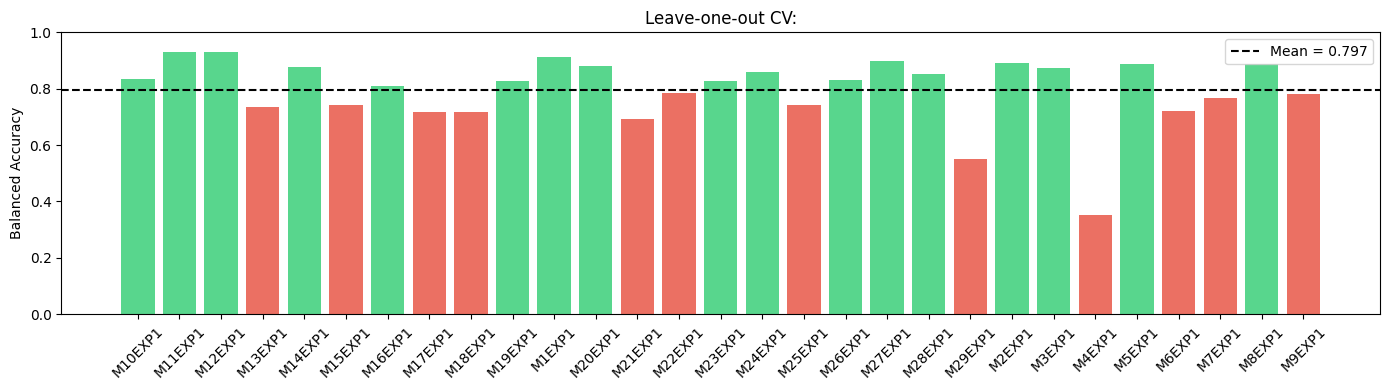

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#e74c3c' if v < 0.8 else '#2ecc71' for v in results_df['balanced_accuracy']]
ax.bar(results_df['mouse'], results_df['balanced_accuracy'], color=colors, alpha=0.8)
ax.axhline(results_df['balanced_accuracy'].mean(), color='black', linestyle='--',
           label=f'Mean = {results_df["balanced_accuracy"].mean():.3f}')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Leave-one-out CV:')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

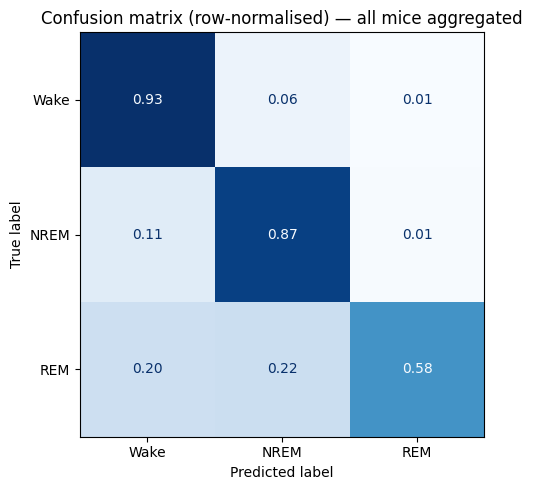

In [10]:
# confusion matrix for all mice
labels = ['w', 'n', 'r']
label_names = ['Wake', 'NREM', 'REM']

cm = confusion_matrix(all_y_true, all_y_pred, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title('Confusion matrix (row-normalised) — all mice aggregated')
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(all_y_true, all_y_pred,
                             target_names=label_names))

              precision    recall  f1-score   support

        Wake       0.88      0.87      0.88    948297
        NREM       0.77      0.58      0.66    135360
         REM       0.91      0.93      0.92   1421943

    accuracy                           0.89   2505600
   macro avg       0.85      0.80      0.82   2505600
weighted avg       0.89      0.89      0.89   2505600



## 5. Feature importance

Trained on all mice together to get stable importance estimates.

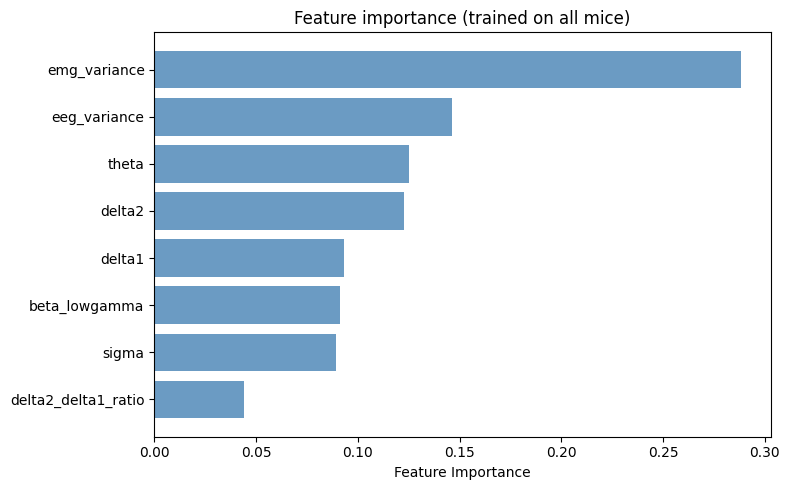

In [12]:
all_df = pd.concat(mouse_dfs.values(), ignore_index=True)
clf_full = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   n_jobs=-1, random_state=42)
clf_full.fit(all_df[FEATURES], all_df[LABEL])

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': clf_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue', alpha=0.8)
ax.set_xlabel('Feature Importance')
ax.set_title('Feature importance (trained on all mice)')
plt.tight_layout()
plt.show()